In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned NAV data
nav = pd.read_csv(
    "data/Processed/nav_history_cleaned.csv"
)

# Load performance data
performance = pd.read_csv(
    "data/Processed/07_scheme_performance_cleaned.csv"
)

# Load benchmark data
benchmark = pd.read_csv(
    "data/Raw/10_benchmark_indices.csv"
)

print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)

NAV: (46000, 3)
Performance: (41, 19)
Benchmark: (8050, 3)


In [3]:
nav.head()
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [4]:
# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Sort data properly
nav = nav.sort_values(
    ["amfi_code", "date"]
)

# Calculate daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove first NaN return rows
nav_returns = nav.dropna(
    subset=["daily_return"]
)

nav_returns.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [5]:
nav_returns["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [6]:
nav_returns["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

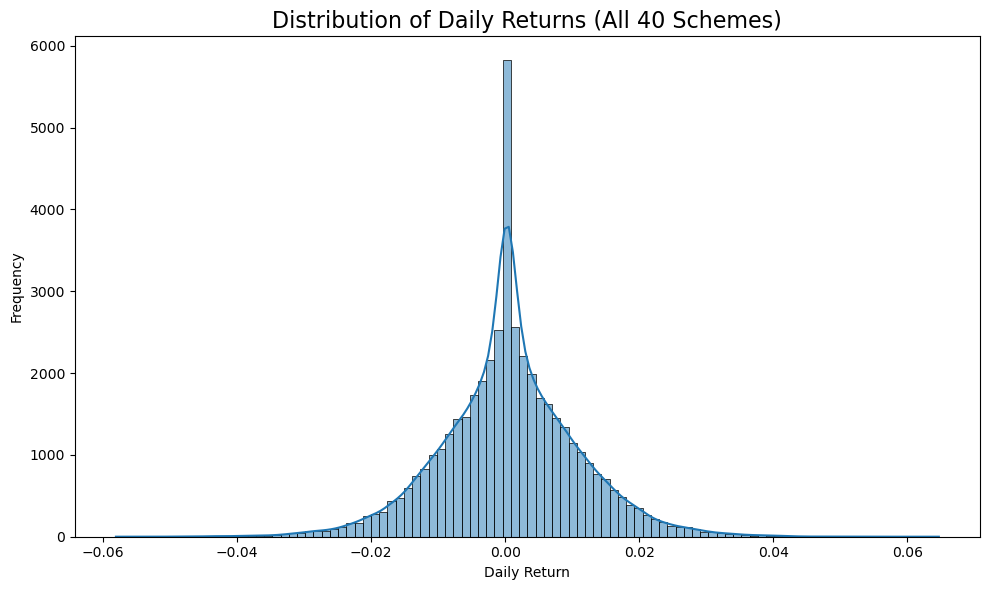

✅ Daily Return Distribution chart saved!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(
    nav_returns["daily_return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns (All 40 Schemes)", fontsize=16)
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

# Save chart
plt.savefig(
    "Charts/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Daily Return Distribution chart saved!")

In [8]:
# Make sure NAV is sorted
nav = nav.sort_values(["amfi_code", "date"])

# Convert date
nav["date"] = pd.to_datetime(nav["date"])


def calculate_cagr(data, years):
    start_date = data["date"].max() - pd.DateOffset(years=years)

    filtered = data[data["date"] >= start_date]

    if len(filtered) == 0:
        return np.nan

    start_nav = filtered.iloc[0]["nav"]
    end_nav = filtered.iloc[-1]["nav"]

    cagr = (end_nav / start_nav) ** (1 / years) - 1

    return cagr * 100


# Calculate CAGR for each fund
cagr_table = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    cagr_table.append({
        "amfi_code": fund,
        "cagr_1yr_pct": calculate_cagr(fund_data, 1),
        "cagr_3yr_pct": calculate_cagr(fund_data, 3),
        "cagr_5yr_pct": calculate_cagr(fund_data, 5)
    })


cagr_df = pd.DataFrame(cagr_table)

cagr_df.head()

,amfi_code,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
0,100016,-2.224271,1.292649,2.316843
1,100025,3.704969,3.916390,3.912653
2,100033,53.232396,32.442459,26.074068
3,101206,47.924120,28.967695,20.442730
4,101207,-23.986032,-4.152381,6.953336


In [9]:
cagr_df.head()

,amfi_code,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
0,100016,-2.224271,1.292649,2.316843
1,100025,3.704969,3.916390,3.912653
2,100033,53.232396,32.442459,26.074068
3,101206,47.924120,28.967695,20.442730
4,101207,-23.986032,-4.152381,6.953336


In [13]:
# Convert AMFI code to string in both datasets
cagr_df["amfi_code"] = cagr_df["amfi_code"].astype(str).str.strip()

performance["amfi_code"] = performance["amfi_code"].astype(str).str.strip()

# Merge CAGR with performance details
cagr_df = cagr_df.merge(
    performance[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

# Arrange columns
cagr_df = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "fund_house",
        "category",
        "cagr_1yr_pct",
        "cagr_3yr_pct",
        "cagr_5yr_pct"
    ]
]

cagr_df.head()

,amfi_code,scheme_name,fund_house,category,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,-2.224271,1.292649,2.316843
1,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,3.704969,3.916390,3.912653
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,53.232396,32.442459,26.074068
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap,47.924120,28.967695,20.442730
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,-23.986032,-4.152381,6.953336


In [11]:
cagr_df.to_csv(
    "cagr_comparison_table.csv",
    index=False
)

print("✅ CAGR comparison table saved!")

✅ CAGR comparison table saved!
